In [ ]:
import os
import re
import json
from datetime import datetime

from langchain_ollama import ChatOllama
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_core.messages import HumanMessage, SystemMessage

MODEL_NAME = "qwen3:8b"
TEMPERATURE = 0
MAX_SEARCH_RESULTS = 5

# BASE_OUTPUT = "outputs"

# DIRS = {
#     "reports": os.path.join(BASE_OUTPUT, "reports"),
#     "metrics": os.path.join(BASE_OUTPUT, "metrics"),
#     "graphs": os.path.join(BASE_OUTPUT, "graphs"),
#     "decomposition": os.path.join(BASE_OUTPUT, "decomposition"),
#     "validation": os.path.join(BASE_OUTPUT, "validation"),
#     "reflection": os.path.join(BASE_OUTPUT, "reflection"),
#     "logs": os.path.join(BASE_OUTPUT, "logs")
# }


# for d in DIRS.values():
#     os.makedirs(d, exist_ok=True)


def timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def save_text(path, text):

    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


def save_json(path, data):

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)




def extract_json(text):

    try:

        match = re.search(
            r"\{.*\}|\[.*\]",
            text,
            re.DOTALL
        )

        if match:
            return json.loads(match.group())

    except Exception:
        pass

    return None


def evaluate_metric(metric_name, query, generated_output):

    system_prompt = "You are an evaluator agent."

    human_prompt = f"""
    Evaluate the output.

    Metric:
    {metric_name}

    Score from 1-10.

    Return STRICT JSON:

    {{
        "score": 8,
        "reason": "..."
    }}

    Query:
    {query}

    Output:
    {generated_output}
    """

    response = invoke_llm(
        system_prompt,
        human_prompt
    )

    parsed = extract_json(response)

    if parsed is None:

        parsed = {
            "score": 5,
            "reason": "Failed parsing"
        }

    return parsed


def evaluate_all_metrics(
    architecture_name,
    query,
    final_answer,
    decomposition=None,
    validation=None,
    reflection=None
):

    metrics = {}

    metrics["answer_depth"] = evaluate_metric(
        "Answer Depth Score",
        query,
        final_answer
    )

    metrics["answer_relevance"] = evaluate_metric(
        "Answer Relevance Score",
        query,
        final_answer
    )

    if decomposition:

        metrics["subquery_quality"] = evaluate_metric(
            "Subquery Quality Score",
            query,
            decomposition
        )

    if validation:

        metrics["source_relevance"] = evaluate_metric(
            "Source Relevance Score",
            query,
            validation
        )

    if reflection:

        metrics["reflection_score"] = evaluate_metric(
            "Reflection Score",
            query,
            reflection
        )

    metrics_path = os.path.join(
        DIRS["metrics"],
        f"{architecture_name}_metrics.json"
    )

    save_json(metrics_path, metrics)

    return metrics


def invoke_llm(system_prompt, human_prompt):

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=human_prompt)
    ]

    response = llm.invoke(messages)

    return response.content

llm = ChatOllama(
    model=MODEL_NAME,
    temperature=TEMPERATURE
)

search_tool = DuckDuckGoSearchResults(
    num_results=MAX_SEARCH_RESULTS
)



In [83]:
from typing import TypedDict, Literal

from langgraph.graph import StateGraph, START, END

# from common_utils import *

MAX_LOOPS = 3
RELEVANCE_THRESHOLD = 7


class State(TypedDict):

    query: str

    messages: list

    plan : str

    instructions: str

    subqueries: list

    sources: list

    validated_sources: list

    reflection: dict

    final_answer: str

    loop_count: int


#### Tools handson

In [16]:
from langchain.tools import tool

@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(search.name)  # web_search

web_search


In [29]:
search

StructuredTool(name='web_search', description='Search the web for information.', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function search at 0x7279a43b4b40>)

In [ ]:
tools = [
    {
        "name": search.name,
        "description": search.description,
        
    }
]

langchain_core.tools.structured.web_search_output

In [31]:
search_tool.get_config_jsonschema()

{'properties': {}, 'title': 'duckduckgo_results_json_config', 'type': 'object'}

In [ ]:
llm_tool = llm.bind_tools([search_tool],tool_choice="required")



messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="When did the Apollo 11 mission land on the moon?")
]

response = llm_tool.invoke(messages)
response


AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-05-15T16:42:47.824205575Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9779909193, 'load_duration': 1540539721, 'prompt_eval_count': 181, 'prompt_eval_duration': 286211154, 'eval_count': 238, 'eval_duration': 7827237230, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019e2c84-c05a-7371-b763-364fc870a5b8-0', tool_calls=[{'name': 'duckduckgo_results_json', 'args': {'query': 'Apollo 11 moon landing date'}, 'id': '266aae9c-7775-4d62-9dce-a7b1ee997cf6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 181, 'output_tokens': 238, 'total_tokens': 419})

In [7]:
response.tool_calls

[{'name': 'duckduckgo_results_json',
  'args': {'query': 'Apollo 11 moon landing date'},
  'id': 'd0de6ca2-1481-4710-84ca-d858786d1728',
  'type': 'tool_call'}]

In [32]:
from typing import List, Dict, Optional, Union
from datetime import datetime
from enum import Enum

class Priority(str, Enum):
    LOW = "low"
    MEDIUM = "medium"
    HIGH = "high"

@tool
def create_task(
    title: str,
    description: Optional[str] = None,
    priority: Priority = Priority.MEDIUM,
    due_date: Optional[datetime] = None,
    tags: List[str] = []
) -> Dict[str, Union[str, int]]:
    """
    Create a new task in the project management system.

    Args:
        title: Task title (required, max 100 characters).
        description: Detailed task description (optional).
        priority: Task priority level (low, medium, high).
        due_date: When the task should be completed (ISO format).
        tags: List of tags to categorize the task.

    Returns:
        Dictionary containing a task ID and a confirmation message.
    """
    if len(title) > 100:
        raise ValueError("Title must be 100 characters or less")
    if due_date and due_date < datetime.now():
        raise ValueError("Due date cannot be in the past")
    task_id = generate_task_id()
    return {
        "task_id": task_id,
        "message": f"Task '{title}' created successfully"
    }
    

In [34]:
create_task.get_config_jsonschema()

{'properties': {}, 'title': 'create_task_config', 'type': 'object'}

In [10]:
from pydantic import BaseModel
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy


class ContactInfo(BaseModel):
    name: str
    email: str
    phone: str

agent = create_agent(
    model=llm,
    tools=[],
    response_format=ToolStrategy(ContactInfo)
)


In [11]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

In [12]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: "}]
})

result["structured_response"]

ContactInfo(name='John Doe', email='john.doe@example.com', phone='123-456-7890')

In [36]:
weather_tool = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current weather for a city",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "Name of the city"
                },
                "units": {
                    "type": "string",
                    "enum": ["celsius", "fahrenheit"],
                    "description": "Temperature unit"
                }
            },
            "required": ["city"]
        }
    }
}

In [39]:
llm_tool

_ChatModelBinding(bound=ChatOllama(output_version=None, model='qwen3:8b', temperature=0.0), kwargs={'tools': [{'type': 'function', 'function': {'name': 'duckduckgo_results_json', 'description': 'A wrapper around Duck Duck Go Search. Useful for when you need to answer questions about current events. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [47]:
llm_with_tools = llm.bind_tools([weather_tool, search_tool], tool_choice="required")


messages = [
    SystemMessage(content="You are a helpful assistant."),
    # HumanMessage(content="When did the Apollo 11 mission land on the moon?")
    HumanMessage(content="what is the weather in Oslo?"),
]

response = llm_with_tools.invoke(messages)
response


AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-05-15T17:25:47.26735454Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6302002474, 'load_duration': 71976755, 'prompt_eval_count': 239, 'prompt_eval_duration': 61701913, 'eval_count': 186, 'eval_duration': 6112847354, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019e2cac-29e3-7172-9592-1ae0697c3f91-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Oslo', 'units': 'celsius'}, 'id': '853b5e45-3cbf-4170-968d-86ea74b155cb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 186, 'total_tokens': 425})

In [48]:
response.content

''

In [49]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'city': 'Oslo', 'units': 'celsius'},
  'id': '853b5e45-3cbf-4170-968d-86ea74b155cb',
  'type': 'tool_call'}]

#### Nodes

In [85]:
# ============================================================
# PLANNING NODE
# ============================================================
PLANNER_PROMPT = """
You are a planning agent.

Generate a research plan.

Analyze the query and generate a step-by-step research plan.
"""

# planner_tool = {
#     "type": "function",
#     "function": {
#         "name": "get_plan",
#         "description": "Get research plan for a query",
#         "parameters": {
#             "type": "object",
#             "properties": {
#                 "query": {
#                     "type": "string",
#                     "description": "The research query"
#                 }
#             },
#             "required": ["query"]
#         }
#     }
# }

def planner_node(state: State):
    """
    Takes the initial query and generates a step-by-step research plan.
    """
    print("=== PLANNING NODE ===")
    print("Current state:", state)
    messages = [
        SystemMessage(content=PLANNER_PROMPT),
        HumanMessage(content=state["query"]),
    ]

    response = llm.invoke(messages)

    print("Planning response:", response)

    state["plan"] = response.content
    state["messages"] = messages + [response]
    
    return state
    # return {
    #     "plan" : response.content,
    #     "messages": response
    # }


In [54]:
planner_output = planner_node({
    "query": "What are the health benefits of green tea?"
})
planner_output

Planning response: content='**Research Plan: Health Benefits of Green Tea**  \n**Objective:** To systematically evaluate the scientific evidence supporting the health benefits of green tea, focusing on its bioactive compounds, mechanisms of action, and clinical outcomes.  \n\n---\n\n### **Step 1: Define Scope and Key Research Questions**  \n- **Primary Focus Areas:**  \n  1. Antioxidant properties and cellular health.  \n  2. Metabolic effects (e.g., weight management, diabetes).  \n  3. Cardiovascular health.  \n  4. Neurological benefits (e.g., cognitive function, neurodegenerative diseases).  \n  5. Cancer prevention.  \n  6. Mental health (e.g., stress reduction, anxiety).  \n  7. Dental and skin health.  \n\n- **Key Questions:**  \n  - What are the bioactive compounds in green tea (e.g., EGCG, catechins, caffeine)?  \n  - How do these compounds influence human health?  \n  - Are there clinically validated benefits for specific conditions?  \n  - What are the limitations of current

{'plan': '**Research Plan: Health Benefits of Green Tea**  \n**Objective:** To systematically evaluate the scientific evidence supporting the health benefits of green tea, focusing on its bioactive compounds, mechanisms of action, and clinical outcomes.  \n\n---\n\n### **Step 1: Define Scope and Key Research Questions**  \n- **Primary Focus Areas:**  \n  1. Antioxidant properties and cellular health.  \n  2. Metabolic effects (e.g., weight management, diabetes).  \n  3. Cardiovascular health.  \n  4. Neurological benefits (e.g., cognitive function, neurodegenerative diseases).  \n  5. Cancer prevention.  \n  6. Mental health (e.g., stress reduction, anxiety).  \n  7. Dental and skin health.  \n\n- **Key Questions:**  \n  - What are the bioactive compounds in green tea (e.g., EGCG, catechins, caffeine)?  \n  - How do these compounds influence human health?  \n  - Are there clinically validated benefits for specific conditions?  \n  - What are the limitations of current research?  \n\n--

In [100]:

# ============================================================
# DECOMPOSER NODE
# ============================================================
DECOMPOSER_PROMPT = """
You are a decomposition agent.
Takes the research plan and decomposes it into focused subqueries.
Rules:
- Avoid overlap
- Make them detailed
- Generate unanswered questions only
Return STRICT JSON LIST.
"""

DECOMPOSER_TOOL = {
    "type": "function",
    "function": {
        "name": "decompose_plan",
        "description": "Decompose research plan into focused subqueries",
        "parameters": {
            "type": "object",
            "properties": {
                "subqueries": {
                    "type": "array",
                    "items": {
                        "type": "string"
                    },
                    "description": "The decomposed subqueries"
                }
            },
            "required": ["subqueries"]
        }
    }
}

USER_DECOMPOSER_PROMPT = """
    Research Plan:
    {plan}
"""   

def decomposer_node(state: State):
    """Takes the research plan and decomposes it into focused subqueries."""
    print("=== DECOMPOSER NODE ===")
    print("Current state:", state)

    messages = [
        SystemMessage(content=DECOMPOSER_PROMPT),
        HumanMessage(content=USER_DECOMPOSER_PROMPT.format(plan=state["plan"])),
    ]
    llm_tool = llm.bind_tools([DECOMPOSER_TOOL], tool_choice="required")
    response = llm_tool.invoke(messages)

    print("Decomposition response:", response.tool_calls)

    sub_queries = response.tool_calls[0].get("args", {}).get("subqueries", [])

    return {
        "subqueries": sub_queries,
        "messages": response    
    }



In [60]:
decomposer_output = decomposer_node({
    "plan": planner_output["plan"]
})
decomposer_output

Decomposition response: [{'name': 'decompose_plan', 'args': {'subqueries': ['What are the specific bioactive compounds in green tea (e.g., EGCG, catechins, caffeine) and their molecular structures?', 'How do polyphenols in green tea neutralize free radicals and reduce oxidative stress at the cellular level?', 'What is the evidence linking green tea consumption to reduced risk of cardiovascular diseases and improved endothelial function?', 'What mechanisms underlie the role of EGCG in fat oxidation, thermogenesis, and metabolic syndrome management?', 'How do caffeine and L-theanine in green tea synergistically affect cognitive function, attention, and stress reduction?', 'What are the clinically validated effects of green tea on insulin sensitivity, glucose metabolism, and type 2 diabetes prevention?', 'What is the role of green tea polyphenols in modulating neuroinflammation and amyloid-beta accumulation in Alzheimer’s disease models?', 'Are there dose-dependent relationships between g

{'subqueries': ['What are the specific bioactive compounds in green tea (e.g., EGCG, catechins, caffeine) and their molecular structures?',
  'How do polyphenols in green tea neutralize free radicals and reduce oxidative stress at the cellular level?',
  'What is the evidence linking green tea consumption to reduced risk of cardiovascular diseases and improved endothelial function?',
  'What mechanisms underlie the role of EGCG in fat oxidation, thermogenesis, and metabolic syndrome management?',
  'How do caffeine and L-theanine in green tea synergistically affect cognitive function, attention, and stress reduction?',
  'What are the clinically validated effects of green tea on insulin sensitivity, glucose metabolism, and type 2 diabetes prevention?',
  'What is the role of green tea polyphenols in modulating neuroinflammation and amyloid-beta accumulation in Alzheimer’s disease models?',
  'Are there dose-dependent relationships between green tea intake and cancer risk reduction for 

In [104]:
# ============================================================
# SEARCH NODE
# ============================================================

def search_node(state: State):

    print("=== SEARCH NODE ===")
    print("Current state:", state)

    all_sources = []

    counter = 0

    for q in state["subqueries"]:

        try:

            results = search_tool.run(str(q))

        except Exception as e:

            results = str(e)

        all_sources.append({
            "question": q,
            "question_id": counter,
            "sources": results
        })
        counter += 1

    # state["sources"] = all_sources

    # save_json(
    #     "outputs/logs/A5_raw_sources.json",
    #     all_sources
    # )

    return {
        "sources": all_sources
    }


In [ ]:

search_output = search_node({
    "subqueries": decomposer_output["subqueries"]
})
search_output

{'all_sources': [{'question': 'What are the specific bioactive compounds in green tea (e.g., EGCG, catechins, caffeine) and their molecular structures?',
   'question_id': 0,
   'sources': "snippet: EGCG—the most abundant catechin in tea—is a polyphenol under basic research for its potential to affect human health and disease. EGCG is used in numerous dietary supplements., title: Epigallocatechin gallate - Wikipedia, link: https://en.wikipedia.org/wiki/Epigallocatechin_gallate, snippet: Japanese matcha is a type of powdered green tea, grown in a traditional way. Shading of the plants during the growth period enhances the processes of synthesis and accumulation of biologically active compounds, including theanine, caffeine, chlorophyll and various types of catechins., title: Health Benefits and Chemical Composition of Matcha Green Tea..., link: https://pubmed.ncbi.nlm.nih.gov/33375458/, snippet: Green tea is prepared from dried leaves of Camellia sinensis, a perennial evergreen shrub. I

In [111]:
# ============================================================
# VALIDATION NODE
# ============================================================
SOURCE_VALIDATION_PROMPT = """
You are a source validation agent.
Validate the retrieved sources for the research question.
"""

USER_VALIDATION_PROMPT = """
Research Question: {question}
Sources: {srcs}
"""

SOURCE_VALIDATION_TOOL = {
    "type": "function",
    "function": {
        "name": "validate_source",
        "description": "Validate the relevance of the source for the research question in terms of whether it provides useful information to answer the research question",
        "parameters": {
            "type": "object",
            "properties": {
                "questions_with_scores": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "question_id": {
                                "type": "integer",
                                "description": "ID of the question"
                            },
                            "score": {
                                "type": "integer",
                                "minimum": 1,
                                "maximum": 10,
                                "description": "Relevance score from 1 to 10"
                            },
                            "reason": {
                                "type": "string",
                                "description": "Reason for the relevance score"
                            }
                        },
                        "required": ["score", "reason"]
                    }
                }
            },
            "required": ["questions_with_scores"]
        }
    }
}

def validation_node(state: State):
    """Validates the relevance of retrieved sources and filters them based on a relevance threshold."""

    # Curretly validating all sources, but ideally we should only validate a subset to save costs
    # And validating one by one, but ideally we could batch them
    print("=== VALIDATION NODE ===")
    print("Current state:", state)

    validated = []

    llm_tool = llm.bind_tools([SOURCE_VALIDATION_TOOL], tool_choice="required")

    if len(state["sources"]) > 5:
        state["sources"] = state["sources"][:5]

    messages = [
        SystemMessage(content=SOURCE_VALIDATION_PROMPT),
        HumanMessage(content=USER_VALIDATION_PROMPT.format(srcs=state["sources"], question=state["query"]))
    ]
    response = None
    for i in range(3):
        response = llm_tool.invoke(messages)

        tool_calls = response.tool_calls
        response_content = response.content
        print("Validation response:", response.tool_calls)
        print("Validation response content:", response.content)

        if tool_calls:
            break
        
        if not tool_calls and not response_content:
            print("No validation response received.")
            # continue
    if response is None:
        print("No response received after multiple attempts.")
        return {
            "validated_sources": []
        }

    parsed = response.tool_calls[0].get("args", {}).get("questions_with_scores", [])

    print("Parsed validation:", parsed)


    # validated.append({
    #     "question": state["query"],
    #     "sources": src["sources"],
    #     "validation": parsed
    # })

    filtered_question_ids = []
    filtered_sources = []

    for item in parsed:
        if item["score"] >= RELEVANCE_THRESHOLD:
            filtered_question_ids.append(item["question_id"])

    for src in state["sources"]:
        if src["question_id"] in filtered_question_ids:
            filtered_sources.append(src)

    # state["validated_sources"] = filtered_sources

    # save_json(
    #     "outputs/validation/A5_validation.json",
    #     filtered_sources
    # )

    return {
        "validated_sources": filtered_sources
    }

In [ ]:


validation_output = validation_node({
    "query": "What are the health benefits of green tea?",
    "all_sources": search_output["all_sources"]
})
validation_output



Validation response: [{'name': 'validate_source', 'args': {'questions_with_scores': [{'question_id': 0, 'reason': 'The sources detail bioactive compounds like EGCG, catechins, caffeine, and theanine in green tea, directly addressing the question.', 'score': 10}, {'question_id': 1, 'reason': 'Sources explain how polyphenols neutralize free radicals, activate antioxidant pathways, and reduce oxidative stress, aligning with the question.', 'score': 10}, {'question_id': 2, 'reason': 'Sources provide evidence linking green tea to cardiovascular benefits, endothelial function, and lipid metabolism, directly answering the question.', 'score': 10}, {'question_id': 3, 'reason': "Sources discuss EGCG's role in fat oxidation, thermogenesis, and metabolic syndrome, directly addressing the mechanisms in the question.", 'score': 9}, {'question_id': 4, 'reason': 'Sources explore the synergistic effects of caffeine and L-theanine on cognition, attention, and stress reduction, directly answering the qu

{'validated_sources': [{'question': 'What are the specific bioactive compounds in green tea (e.g., EGCG, catechins, caffeine) and their molecular structures?',
   'question_id': 0,
   'sources': "snippet: EGCG—the most abundant catechin in tea—is a polyphenol under basic research for its potential to affect human health and disease. EGCG is used in numerous dietary supplements., title: Epigallocatechin gallate - Wikipedia, link: https://en.wikipedia.org/wiki/Epigallocatechin_gallate, snippet: Japanese matcha is a type of powdered green tea, grown in a traditional way. Shading of the plants during the growth period enhances the processes of synthesis and accumulation of biologically active compounds, including theanine, caffeine, chlorophyll and various types of catechins., title: Health Benefits and Chemical Composition of Matcha Green Tea..., link: https://pubmed.ncbi.nlm.nih.gov/33375458/, snippet: Green tea is prepared from dried leaves of Camellia sinensis, a perennial evergreen sh

In [106]:

# ============================================================
# REFLECTION NODE
# ============================================================

REFLECTION_PROMPT = """
You are a reflection agent.
Determine whether more research is needed.
Analyze:
- Missing information
- Weak coverage
- Missing comparisons
- Missing benchmarks
"""


REFLECTION_TOOL = {
    "type": "function",
    "function": {
        "name": "reflect_on_sources",
        "description": "Reflect on the validated sources and determine if more research is needed. Provide instructions for the next iteration if needed.",
        "parameters": {
            "type": "object",
            "properties": {
                "info_needed": {
                    "type": "boolean",
                    "description": "Whether more information is needed"
                },
                "instructions": {
                    "type": "string",
                    "description": "Instructions for the next iteration if more information is needed"
                }
            },
            "required": ["info_needed", "instructions"]
        }
    }
}

USER_PROMPT = """
Query:
{query}
Validated Sources:
{validated_sources}
"""



def reflection_node(state: State):

    print("=== REFLECTION NODE ===")
    print("Current state:", state)

    llm_tool = llm.bind_tools([REFLECTION_TOOL], tool_choice="required")

    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=USER_PROMPT.format(query=state["query"], validated_sources=state["validated_sources"]))
    ]
    response = llm_tool.invoke(messages)

    print("Reflection response:", response.tool_calls)

    parsed = response.tool_calls[0].get("args", {})

    state["reflection"] = parsed

    state["instructions"] = parsed[
        "instructions"
    ]

    state["loop_count"] += 1

    # save_json(
    #     "outputs/reflection/A5_reflection.json",
    #     parsed
    # )

    return state


In [ ]:

reflection_output = reflection_node({
    "query": "What are the health benefits of green tea?",
    "validated_sources": validation_output["validated_sources"],
    "loop_count": 0
})
reflection_output



Reflection response: [{'name': 'reflect_on_sources', 'args': {'info_needed': True, 'instructions': "To provide a comprehensive answer on the health benefits of green tea, additional research is needed. Specifically, gather: (1) Detailed molecular structures of bioactive compounds like EGCG and catechins, (2) Comparative analyses of green tea antioxidants vs. other antioxidants, (3) Long-term cardiovascular outcome studies with diverse populations, (4) Mechanistic comparisons of EGCG's effects on metabolic syndrome vs. other compounds, and (5) Meta-analyses of caffeine-L-theanine synergy across different cognitive tasks. Prioritize recent studies (post-2025) and clinical trial data."}, 'id': 'b4bcff68-9781-41d6-9ab5-91e8e62a18a8', 'type': 'tool_call'}]


{'query': 'What are the health benefits of green tea?',
 'validated_sources': [{'question': 'What are the specific bioactive compounds in green tea (e.g., EGCG, catechins, caffeine) and their molecular structures?',
   'question_id': 0,
   'sources': "snippet: EGCG—the most abundant catechin in tea—is a polyphenol under basic research for its potential to affect human health and disease. EGCG is used in numerous dietary supplements., title: Epigallocatechin gallate - Wikipedia, link: https://en.wikipedia.org/wiki/Epigallocatechin_gallate, snippet: Japanese matcha is a type of powdered green tea, grown in a traditional way. Shading of the plants during the growth period enhances the processes of synthesis and accumulation of biologically active compounds, including theanine, caffeine, chlorophyll and various types of catechins., title: Health Benefits and Chemical Composition of Matcha Green Tea..., link: https://pubmed.ncbi.nlm.nih.gov/33375458/, snippet: Green tea is prepared from dri

In [107]:

# ============================================================
# SYNTHESIS NODE
# ============================================================

SYNTHESIS_PROMPT = """
You are a deep research synthesis agent.
Generate a comprehensive markdown report.
Include:
- Introduction
- Technical Analysis
- Comparisons
- Benchmarks
- Limitations
- Conclusion
- References
"""

USER_PROMPT = """
Query:
{query}
Validated Sources:
{validated_sources}
"""


def synthesis_node(state: State):
    print("=== SYNTHESIS NODE ===")
    print("Current state:", state)
    
    messages = [
        SystemMessage(content=SYNTHESIS_PROMPT),
        HumanMessage(content=USER_PROMPT.format(query=state["query"], validated_sources=state["validated_sources"]))
    ]
    response = llm.invoke(messages)

    state["final_answer"] = response

    return state


In [ ]:

synthesis_output = synthesis_node({
    "query": "What are the health benefits of green tea?",
    "validated_sources": validation_output["validated_sources"]
})
synthesis_output



{'query': 'What are the health benefits of green tea?',
 'validated_sources': [{'question': 'What are the specific bioactive compounds in green tea (e.g., EGCG, catechins, caffeine) and their molecular structures?',
   'question_id': 0,
   'sources': "snippet: EGCG—the most abundant catechin in tea—is a polyphenol under basic research for its potential to affect human health and disease. EGCG is used in numerous dietary supplements., title: Epigallocatechin gallate - Wikipedia, link: https://en.wikipedia.org/wiki/Epigallocatechin_gallate, snippet: Japanese matcha is a type of powdered green tea, grown in a traditional way. Shading of the plants during the growth period enhances the processes of synthesis and accumulation of biologically active compounds, including theanine, caffeine, chlorophyll and various types of catechins., title: Health Benefits and Chemical Composition of Matcha Green Tea..., link: https://pubmed.ncbi.nlm.nih.gov/33375458/, snippet: Green tea is prepared from dri

In [92]:

# ============================================================
# ROUTER
# ============================================================

def router(state: State) -> Literal[
    "decomposer_node",
    "synthesis_node"
]:
    print("=== ROUTER ===")
    print("Current state:", state)

    if state["loop_count"] >= MAX_LOOPS:
        return "synthesis_node"

    if state["reflection"]["info_needed"]:
        return "decomposer_node"

    return "synthesis_node"



In [112]:

# ============================================================
# BUILD GRAPH
# ============================================================

graph = StateGraph(State)

graph.add_node(
    "planner_node",
    planner_node
)

graph.add_node(
    "decomposer_node",
    decomposer_node
)

graph.add_node(
    "search_node",
    search_node
)

graph.add_node(
    "validation_node",
    validation_node
)

graph.add_node(
    "reflection_node",
    reflection_node
)

graph.add_node(
    "synthesis_node",
    synthesis_node
)

# ============================================================
# FLOW
# ============================================================

graph.add_edge(
    START,
    "planner_node"
)

graph.add_edge(
    "planner_node",
    "decomposer_node"
)

graph.add_edge(
    "decomposer_node",
    "search_node"
)

graph.add_edge(
    "search_node",
    "validation_node"
)

graph.add_edge(
    "validation_node",
    "reflection_node"
)

graph.add_conditional_edges(
    "reflection_node",
    router
)

graph.add_edge(
    "synthesis_node",
    END
)

# ============================================================
# COMPILE
# ============================================================

from langgraph.checkpoint.memory import InMemorySaver  

checkpointer = InMemorySaver()

app = graph.compile(checkpointer=checkpointer)

# app.get_graph().draw_mermaid_png(
#     output_file_path="outputs/graphs/A5_graph.png"
# )



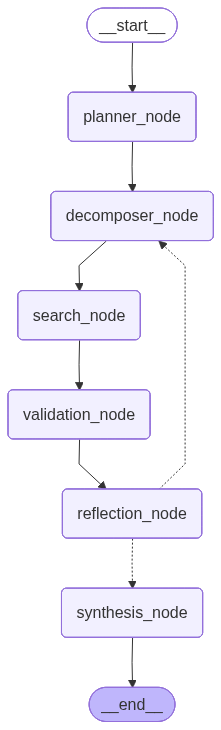

In [113]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
query = "What are the health benefits of green tea?"

config = {"configurable": {"thread_id": "1"}}
state = {
    "query": query,
    "loop_count": 0
}


final_state = app.invoke(state, config)

=== PLANNING NODE ===
Current state: {'query': 'What are the health benefits of green tea?', 'loop_count': 0}
Planning response: content='**Research Plan: Health Benefits of Green Tea**  \n**Objective:** Investigate the scientific evidence supporting the health benefits of green tea, focusing on its bioactive compounds, mechanisms of action, and clinical outcomes.  \n\n---\n\n### **Step 1: Define Scope and Key Areas of Interest**  \n- **Primary Focus Areas:**  \n  1. Antioxidant properties (e.g., EGCG, catechins).  \n  2. Metabolic health (weight loss, fat oxidation).  \n  3. Cardiovascular benefits (cholesterol, blood pressure).  \n  4. Neuroprotection (Alzheimer’s, Parkinson’s).  \n  5. Cancer prevention (anti-carcinogenic compounds).  \n  6. Mental health (stress reduction, cognitive function).  \n  7. Dental and skin health.  \n\n---\n\n### **Step 2: Literature Search and Curation**  \n- **Sources:**  \n  - Peer-reviewed journals (e.g., *Journal of Agricultural and Food Chemistry*,

In [117]:
final_state['final_answer'].content

"# Health Benefits of Green Tea: A Comprehensive Analysis\n\n---\n\n## Introduction  \nGreen tea, derived from the *Camellia sinensis* plant, has been a staple in traditional medicine for centuries. Its popularity as a functional beverage is driven by its rich bioactive compounds, such as catechins and epigallocatechin gallate (EGCG), which are linked to numerous health benefits. This report synthesizes scientific evidence on green tea's role in cardiovascular health, its bioactive compounds, and its potential anti-carcinogenic properties. The analysis draws from peer-reviewed studies, clinical trials, and mechanistic research to evaluate the efficacy and limitations of green tea as a health intervention.\n\n---\n\n## Technical Analysis  \n\n### 1. **Cardiovascular Health**  \nGreen tea has shown promise in improving cardiometabolic biomarkers, including cholesterol and blood pressure.  \n- **Cholesterol Management**:  \n  A 6-week intervention study found that green tea consumption si

In [6]:
LANGFUSE_SECRET_KEY="sk-lf-f3310337-d8ec-4364-84ac-1668d59ba380"
LANGFUSE_PUBLIC_KEY="pk-lf-2c8a83a3-a53f-44ea-a333-0730ecadc80b"
LANGFUSE_BASE_URL="https://us.cloud.langfuse.com"

from langfuse import get_client
from langfuse.langchain import CallbackHandler
import os

os.environ["LANGFUSE_SECRET_KEY"] = LANGFUSE_SECRET_KEY
os.environ["LANGFUSE_PUBLIC_KEY"] = LANGFUSE_PUBLIC_KEY
os.environ["LANGFUSE_BASE_URL"] = LANGFUSE_BASE_URL

# Initialize Langfuse client
langfuse = get_client()

# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()

In [7]:
# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")

Langfuse client is authenticated and ready!


In [12]:
from langfuse import observe

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.config import get_stream_writer
from langfuse.langchain import CallbackHandler
# Initialize Langfuse CallbackHandler for Langchain (tracing)
langfuse_handler = CallbackHandler()




class State(TypedDict):
    topic: str
    joke: str

@observe
def get_joke(topic: str) -> str:
    return f"Why did the {topic} go to school? To get a sundae education!"

@observe
def generate_joke(state: State):
    writer = get_stream_writer()
    writer({"status": "thinking of a joke..."})
    joke = get_joke(state["topic"])
    langfuse.update_current_generation(
        input={"state": state},
        output={"joke": joke}
    )
    return {"joke": f"Why did the {state['topic']} go to school? To get a sundae education!"}

graph = (
    StateGraph(State)
    .add_node(generate_joke)
    .add_edge(START, "generate_joke")
    .add_edge("generate_joke", END)
    .compile()
)

for chunk in graph.stream(
    {"topic": "ice cream"},
    stream_mode=["updates", "custom"],
    config={"callbacks": [langfuse_handler]},
    version="v2",
):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node {node_name} updated: {state}")
    elif chunk["type"] == "custom":
        print(f"Status: {chunk['data']['status']}")



Status: thinking of a joke...
Node generate_joke updated: {'joke': 'Why did the ice cream go to school? To get a sundae education!'}


In [ ]:
graph.

AttributeError: 'CompiledStateGraph' object has no attribute 'output'

In [12]:
stream = graph.stream_events(
    {"topic": "ice cream"}
    # "messages": [{"role": "user", "content": "What is 42 * 17?"}],
, version="v3")

for event in stream.values:
    print("Event:", event)
    # print(f"Custom event: {event['params']['data']['status']}")

# for event in stream:
#     namespace = event["params"]["namespace"]
#     print(namespace, event["method"], event["params"]["data"])

final_state = stream.output

Event: {'topic': 'ice cream'}
Event: {'topic': 'ice cream', 'joke': 'Why did the ice cream go to school? To get a sundae education!'}


In [13]:
final_state

{'topic': 'ice cream',
 'joke': 'Why did the ice cream go to school? To get a sundae education!'}

'**Research Plan: Health Benefits of Green Tea**  \n**Objective:** Investigate the scientific evidence supporting the health benefits of green tea, focusing on its bioactive compounds, mechanisms of action, and clinical outcomes.  \n\n---\n\n### **Step 1: Define Scope and Key Areas of Interest**  \n- **Primary Focus Areas:**  \n  1. Antioxidant properties (e.g., EGCG, catechins).  \n  2. Metabolic health (weight loss, fat oxidation).  \n  3. Cardiovascular benefits (cholesterol, blood pressure).  \n  4. Neuroprotection (Alzheimer’s, Parkinson’s).  \n  5. Cancer prevention (anti-carcinogenic compounds).  \n  6. Mental health (stress reduction, cognitive function).  \n  7. Dental and skin health.  \n\n---\n\n### **Step 2: Literature Search and Curation**  \n- **Sources:**  \n  - Peer-reviewed journals (e.g., *Journal of Agricultural and Food Chemistry*, *Nutrients*, *Cancer Epidemiology, Biomarkers & Prevention*).  \n  - Meta-analyses and systematic reviews (e.g., Cochrane Library, PubMed).  \n  - Government health agencies (e.g., WHO, NIH).  \n  - Reputable health organizations (e.g., Mayo Clinic, Harvard T.H. Chan School of Public Health).  \n\n- **Search Terms:**  \n  - "Green tea health benefits," "EGCG mechanisms," "green tea and cardiovascular health," "green tea cancer prevention," "green tea and weight loss."  \n  - Include keywords like "clinical trials," "human studies," "long-term effects," and "dose-dependent outcomes."  \n\n---\n\n### **Step 3: Analyze Key Compounds and Mechanisms**  \n- **Bioactive Compounds:**  \n  - Catechins (e.g., EGCG, EGC, ECG).  \n  - L-theanine (amino acid linked to relaxation).  \n  - Flavonoids and polyphenols.  \n- **Mechanisms of Action:**  \n  - Antioxidant activity (neutralizing free radicals).  \n  - Anti-inflammatory effects.  \n  - Modulation of metabolic pathways (e.g., AMPK activation).  \n  - Neuroprotective pathways (e.g., inhibition of amyloid-beta aggregation).  \n\n---\n\n### **Step 4: Evaluate Clinical Evidence**  \n- **Weight Management:**  \n  - Studies on green tea’s impact on thermogenesis and fat oxidation.  \n  - Meta-analysis of randomized controlled trials (RCTs).  \n- **Cardiovascular Health:**  \n  - Longitudinal studies linking green tea consumption to reduced risk of heart disease.  \n  - Trials on LDL cholesterol and blood pressure.  \n- **Cancer Prevention:**  \n  - Epidemiological studies (e.g., reduced risk of breast, prostate, or colorectal cancer).  \n  - In vitro and animal studies on anti-carcinogenic effects.  \n- **Neurodegenerative Diseases:**  \n  - Evidence from observational studies and preclinical models.  \n\n---\n\n### **Step 5: Address Limitations and Controversies**  \n- **Confounding Factors:**  \n  - Variability in tea preparation (e.g., brewing time, temperature).  \n  - Differences in tea quality and source (e.g., Camellia sinensis cultivars).  \n- **Dosage and Duration:**  \n  - Optimal intake for health benefits (e.g., 3–5 cups/day).  \n  - Long-term vs. short-term effects.  \n- **Potential Risks:**  \n  - Caffeine content and its impact on sleep or anxiety.  \n  - Interactions with medications (e.g., anticoagulants).  \n\n---\n\n### **Step 6: Synthesize Findings and Prioritize Evidence**  \n- **Rank Benefits by Strength of Evidence:**  \n  - Strongest: Antioxidant activity, cardiovascular benefits, and metabolic effects.  \n  - Moderate: Neuroprotection, cancer prevention.  \n  - Limited: Mental health and skin benefits.  \n- **Highlight Consensus vs. Emerging Research:**  \n  - Areas with broad agreement (e.g., EGCG’s antioxidant role).  \n  - Areas requiring further study (e.g., long-term cancer risk reduction).  \n\n---\n\n### **Step 7: Provide Practical Recommendations**  \n- **Consumption Guidelines:**  \n  - Suggested daily intake (e.g., 2–3 cups of brewed green tea).  \n  - Tips for maximizing benefits (e.g., avoiding excessive caffeine).  \n- **Integration into Diet:**  \n  - Pairing with other healthy habits (e.g., exercise, balanced diet).  \n\n---\n\n### **Step 8: Communicate Results**  \n- **Summary Report:**  \n  - Evidence-based benefits, limitations, and recommendations.  \n- **Visual Aids:**  \n  - Infographics on key compounds and mechanisms.  \n  - Tables comparing studies (e.g., sample sizes, outcomes).  \n- **Target Audience:**  \n  - General public (practical advice), healthcare professionals (clinical insights), researchers (methodological details).  \n\n---\n\n**Final Output:** A structured, evidence-based summary of green tea’s health benefits, supported by scientific studies, with actionable recommendations for consumers.'

In [ ]:
'**Research Plan: Health Benefits of Green Tea**  \n**Objective:** Investigate the scientific evidence supporting the health benefits of green tea, focusing on its bioactive compounds, mechanisms of action, and clinical outcomes.  \n\n---\n\n### **Step 1: Define Scope and Key Areas of Interest**  \n- **Primary Focus Areas:**  \n  1. Antioxidant properties (e.g., EGCG, catechins).  \n  2. Metabolic health (weight loss, fat oxidation).  \n  3. Cardiovascular benefits (cholesterol, blood pressure).  \n  4. Neuroprotection (Alzheimer’s, Parkinson’s).  \n  5. Cancer prevention (anti-carcinogenic compounds).  \n  6. Mental health (stress reduction, cognitive function).  \n  7. Dental and skin health.  \n\n---\n\n### **Step 2: Literature Search and Curation**  \n- **Sources:**  \n  - Peer-reviewed journals (e.g., *Journal of Agricultural and Food Chemistry*, *Nutrients*, *Cancer Epidemiology, Biomarkers & Prevention*).  \n  - Meta-analyses and systematic reviews (e.g., Cochrane Library, PubMed).  \n  - Government health agencies (e.g., WHO, NIH).  \n  - Reputable health organizations (e.g., Mayo Clinic, Harvard T.H. Chan School of Public Health).  \n\n- **Search Terms:**  \n  - "Green tea health benefits," "EGCG mechanisms," "green tea and cardiovascular health," "green tea cancer prevention," "green tea and weight loss."  \n  - Include keywords like "clinical trials," "human studies," "long-term effects," and "dose-dependent outcomes."  \n\n---\n\n### **Step 3: Analyze Key Compounds and Mechanisms**  \n- **Bioactive Compounds:**  \n  - Catechins (e.g., EGCG, EGC, ECG).  \n  - L-theanine (amino acid linked to relaxation).  \n  - Flavonoids and polyphenols.  \n- **Mechanisms of Action:**  \n  - Antioxidant activity (neutralizing free radicals).  \n  - Anti-inflammatory effects.  \n  - Modulation of metabolic pathways (e.g., AMPK activation).  \n  - Neuroprotective pathways (e.g., inhibition of amyloid-beta aggregation).  \n\n---\n\n### **Step 4: Evaluate Clinical Evidence**  \n- **Weight Management:**  \n  - Studies on green tea’s impact on thermogenesis and fat oxidation.  \n  - Meta-analysis of randomized controlled trials (RCTs).  \n- **Cardiovascular Health:**  \n  - Longitudinal studies linking green tea consumption to reduced risk of heart disease.  \n  - Trials on LDL cholesterol and blood pressure.  \n- **Cancer Prevention:**  \n  - Epidemiological studies (e.g., reduced risk of breast, prostate, or colorectal cancer).  \n  - In vitro and animal studies on anti-carcinogenic effects.  \n- **Neurodegenerative Diseases:**  \n  - Evidence from observational studies and preclinical models.  \n\n---\n\n### **Step 5: Address Limitations and Controversies**  \n- **Confounding Factors:**  \n  - Variability in tea preparation (e.g., brewing time, temperature).  \n  - Differences in tea quality and source (e.g., Camellia sinensis cultivars).  \n- **Dosage and Duration:**  \n  - Optimal intake for health benefits (e.g., 3–5 cups/day).  \n  - Long-term vs. short-term effects.  \n- **Potential Risks:**  \n  - Caffeine content and its impact on sleep or anxiety.  \n  - Interactions with medications (e.g., anticoagulants).  \n\n---\n\n### **Step 6: Synthesize Findings and Prioritize Evidence**  \n- **Rank Benefits by Strength of Evidence:**  \n  - Strongest: Antioxidant activity, cardiovascular benefits, and metabolic effects.  \n  - Moderate: Neuroprotection, cancer prevention.  \n  - Limited: Mental health and skin benefits.  \n- **Highlight Consensus vs. Emerging Research:**  \n  - Areas with broad agreement (e.g., EGCG’s antioxidant role).  \n  - Areas requiring further study (e.g., long-term cancer risk reduction).  \n\n---\n\n### **Step 7: Provide Practical Recommendations**  \n- **Consumption Guidelines:**  \n  - Suggested daily intake (e.g., 2–3 cups of brewed green tea).  \n  - Tips for maximizing benefits (e.g., avoiding excessive caffeine).  \n- **Integration into Diet:**  \n  - Pairing with other healthy habits (e.g., exercise, balanced diet).  \n\n---\n\n### **Step 8: Communicate Results**  \n- **Summary Report:**  \n  - Evidence-based benefits, limitations, and recommendations.  \n- **Visual Aids:**  \n  - Infographics on key compounds and mechanisms.  \n  - Tables comparing studies (e.g., sample sizes, outcomes).  \n- **Target Audience:**  \n  - General public (practical advice), healthcare professionals (clinical insights), researchers (methodological details).  \n\n---\n\n**Final Output:** A structured, evidence-based summary of green tea’s health benefits, supported by scientific studies, with actionable recommendations for consumers.'

### Streaming


In [18]:
!pip install langchain_ollama

  Using cached langchain_ollama-1.1.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached ollama-0.6.2-py3-none-any.whl.metadata (5.8 kB)
Using cached langchain_ollama-1.1.0-py3-none-any.whl (31 kB)
Using cached ollama-0.6.2-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain_ollama]


In [12]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, List
from langgraph.config import get_stream_writer

# ============================================================
# SIMULATED NODES (WITHOUT LLM CALLS)
# ============================================================

class State(TypedDict):
    query: str
    plan: str
    subqueries: List[str]
    sources: List[dict]
    validated_sources: List[dict]
    reflection: dict
    instructions: str
    loop_count: int
    messages: List
    final_answer: str



def planner_node_sim(state: State):
    """Simulated planning node - returns a mock plan."""
    print("=== PLANNING NODE (SIMULATED) ===")
    my_stream_writer = get_stream_writer()
    my_stream_writer({"status": "Planning research approach..."})
    state["plan"] = "Mock research plan for: " + state["query"]
    state["messages"] = []
    return state


def decomposer_node_sim(state: State):
    """Simulated decomposer node - returns mock subqueries."""
    print("=== DECOMPOSER NODE (SIMULATED) ===")
    my_stream_writer = get_stream_writer()
    my_stream_writer({"status": "Decomposing research plan into subqueries..."})
    mock_subqueries = [
        "What are the main antioxidants in green tea?",
        "How does green tea affect metabolism?",
        "What is the scientific evidence for green tea health benefits?"
    ]
    return {
        "subqueries": mock_subqueries,
        "messages": []
    }


def search_node_sim(state: State):
    """Simulated search node - returns mock sources."""
    print("=== SEARCH NODE (SIMULATED) ===")
    my_stream_writer = get_stream_writer()
    my_stream_writer({"status": "Searching for relevant sources..."})
    mock_sources = [
        {
            "question": q,
            "question_id": i,
            "sources": f"Mock search results for: {q}"
        }
        for i, q in enumerate(state["subqueries"])
    ]
    return {
        "sources": mock_sources
    }


def validation_node_sim(state: State):
    """Simulated validation node - returns mock validated sources."""
    print("=== VALIDATION NODE (SIMULATED) ===")
    my_stream_writer = get_stream_writer()
    my_stream_writer({"status": "Validating sources..."})
    mock_validated = state["sources"][:2]  # Keep first 2 sources
    return {
        "validated_sources": mock_validated
    }


def reflection_node_sim(state: State):
    """Simulated reflection node - returns mock reflection."""
    print("=== REFLECTION NODE (SIMULATED) ===")
    my_stream_writer = get_stream_writer()
    my_stream_writer({"status": "Reflecting on the research..."})
    state["reflection"] = {
        "info_needed": False,
        "instructions": "Proceed to synthesis"
    }
    state["instructions"] = "Proceed to synthesis"
    state["loop_count"] += 1
    return state



SYNTHESIS_PROMPT = """
You are a deep research synthesis agent.
Generate a comprehensive markdown report using the comprehensive information gathered.

Instructions:
1. The report should be structured with clear sections and headings.
2. Include a summary of key findings at the beginning.
3. Provide detailed explanations and reasoning for each conclusion.
4. Ensure all claims are supported by the provided evidence.
5. Use clear and precise language suitable for an academic audience.
6. Include citations for all sources of information.
7. Avoid including any information that is not directly supported by the provided evidence.
8. The report should be comprehensive and cover all aspects of the research question.
9. The report should be informative and provide valuable insights based on the evidence.
10. List all the sources used in the synthesis at the end of the report.
"""
from langchain_ollama import ChatOllama
MODEL_NAME = "qwen3:8b"
TEMPERATURE = 0
llm = ChatOllama(
    model=MODEL_NAME,
    temperature=TEMPERATURE
)

def synthesis_node_sim(state: State):
    """Simulated synthesis node with an actual llm call."""
    print("=== SYNTHESIS NODE (SIMULATED) ===")
    my_stream_writer = get_stream_writer()
    my_stream_writer({"status": "Synthesizing final answer..."})
    USER_PROMPT = """
        Query:
        {query}
        Validated Sources:
        {validated_sources}
        """
    messages = [
        SystemMessage(content=SYNTHESIS_PROMPT),
        HumanMessage(content=USER_PROMPT.format(
            query=state["query"],
            validated_sources=state["validated_sources"]
        )),
    ]
    response = llm.invoke(messages)
    state["final_answer"] = response
    return state

from typing import Literal
def router_sim(state: State) -> Literal[
    "decomposer_node",
    "synthesis_node"
]:
    print("=== ROUTER (SIMULATED) ===")
    print("Current state:", state)

    if state["loop_count"] >= MAX_LOOPS:
        return "synthesis_node"

    if state["reflection"]["info_needed"]:
        return "decomposer_node"

    return "synthesis_node"

sim_graph = StateGraph(State)

sim_graph.add_node("planner_node", planner_node_sim)
sim_graph.add_node("decomposer_node", decomposer_node_sim)
sim_graph.add_node("search_node", search_node_sim)
sim_graph.add_node("validation_node", validation_node_sim)
sim_graph.add_node("reflection_node", reflection_node_sim)
sim_graph.add_node("synthesis_node", synthesis_node_sim)

sim_graph.add_edge(START, "planner_node")
sim_graph.add_edge("planner_node", "decomposer_node")
sim_graph.add_edge("decomposer_node", "search_node")
sim_graph.add_edge("search_node", "validation_node")
sim_graph.add_edge("validation_node", "reflection_node")
sim_graph.add_conditional_edges("reflection_node", router_sim)
sim_graph.add_edge("synthesis_node", END)

sim_checkpointer = InMemorySaver()
sim_app = sim_graph.compile(checkpointer=sim_checkpointer)

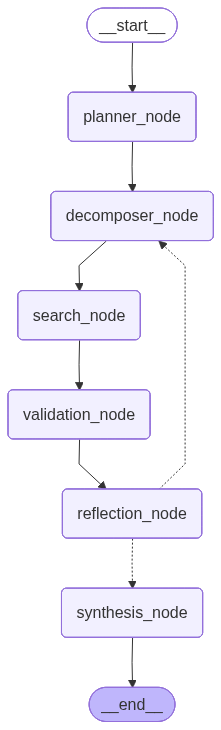

In [13]:
from IPython.display import Image, display
display(Image(sim_app.get_graph().draw_mermaid_png()))

In [ ]:
for chunk in sim_app.stream(
    {
        "query": "What are the health benefits of green tea?",
        "loop_count": 0
    },
    {"configurable": {"thread_id": "sim_thread"}},
    stream_mode=["updates", "custom", "messages"],
    version="v2"
):
    if chunk["type"] == "updates":
        print("=== Mode : UPDATES ===")
        print("Chunk:", chunk)
        for node_name, state in chunk["data"].items():
            print(f"Node {node_name} updated: {state}")
    elif chunk["type"] == "custom":
        print("=== Mode : CUSTOM ===")
        print("Chunk:", chunk)
        print(f"Status: {chunk['data']['status']}")
    elif chunk["type"] == "messages":
        # print("Chunk:", chunk)
        if chunk["data"][0].content:
            print(f"{chunk['data'][0].content} | ", end=" ")

=== PLANNING NODE (SIMULATED) ===
=== Mode : CUSTOM ===
Chunk: {'type': 'custom', 'ns': (), 'data': {'status': 'Planning research approach...'}}
Status: Planning research approach...
=== Mode : UPDATES ===
Chunk: {'type': 'updates', 'ns': (), 'data': {'planner_node': {'query': 'What are the health benefits of green tea?', 'loop_count': 0, 'plan': 'Mock research plan for: What are the health benefits of green tea?', 'messages': []}}}
Node planner_node updated: {'query': 'What are the health benefits of green tea?', 'loop_count': 0, 'plan': 'Mock research plan for: What are the health benefits of green tea?', 'messages': []}
=== DECOMPOSER NODE (SIMULATED) ===
=== Mode : CUSTOM ===
Chunk: {'type': 'custom', 'ns': (), 'data': {'status': 'Decomposing research plan into subqueries...'}}
Status: Decomposing research plan into subqueries...
=== Mode : UPDATES ===
Chunk: {'type': 'updates', 'ns': (), 'data': {'decomposer_node': {'subqueries': ['What are the main antioxidants in green tea?', 'H

In [9]:
async for chunk in sim_app.astream(
    {
        "query": "What are the health benefits of green tea?",
        "loop_count": 0
    },
    {"configurable": {"thread_id": "sim_thread"}},
    stream_mode=["updates", "custom", "messages"],
    version="v2"
):
    if chunk["type"] == "updates":
        print("=== Mode : UPDATES ===")
        print("Chunk:", chunk)
        for node_name, state in chunk["data"].items():
            print(f"Node {node_name} updated: {state}")
    elif chunk["type"] == "custom":
        print("=== Mode : CUSTOM ===")
        print("Chunk:", chunk)
        print(type(chunk["data"]))
        print(f"Status: {chunk['data']['status']}")
    elif chunk["type"] == "messages":
        # print("Chunk:", chunk)
        # print(chunk["data"][0])
        # print(type(chunk["data"]))
        # node_name = chunk["data"][1].get("langgraph_node", "")
        # print(f"Message from node {node_name}: {chunk['data'][0].content}")
        # if chunk["data"][0].content:
            # print(f"{chunk['data'][0].content} | ", end=" ")
        chunk_data = chunk.get("data", ())
        messages = chunk_data[0] if len(chunk_data) > 0 else None
        node_name = chunk_data[1].get("langgraph_node", "") if len(chunk_data) > 1 else ""
        if node_name == "synthesis_node" and messages and messages.content:
            print(f"{chunk_data[0].content} | ", end=" ")
            # break

=== PLANNING NODE (SIMULATED) ===
=== Mode : CUSTOM ===
Chunk: {'type': 'custom', 'ns': (), 'data': {'status': 'Planning research approach...'}}
<class 'dict'>
Status: Planning research approach...
=== Mode : UPDATES ===
Chunk: {'type': 'updates', 'ns': (), 'data': {'planner_node': {'query': 'What are the health benefits of green tea?', 'plan': 'Mock research plan for: What are the health benefits of green tea?', 'subqueries': ['What are the main antioxidants in green tea?', 'How does green tea affect metabolism?', 'What is the scientific evidence for green tea health benefits?'], 'sources': [{'question': 'What are the main antioxidants in green tea?', 'question_id': 0, 'sources': 'Mock search results for: What are the main antioxidants in green tea?'}, {'question': 'How does green tea affect metabolism?', 'question_id': 1, 'sources': 'Mock search results for: How does green tea affect metabolism?'}, {'question': 'What is the scientific evidence for green tea health benefits?', 'questi

In [44]:
### calling fastapi backend server

import requests

url = "http://localhost:8001/get_stream"
body = {
  "question": "Compare DeepSeek-R1 reinforcement learning with OpenAI o3 reasoning tiers. Analyze compute efficiency, benchmark performance, and scaling approaches.",
  "max_iterations": 3,
  "session_id": "2"
}


response = requests.post(
    url,
    json=body
)

KeyboardInterrupt: 

In [6]:
# import httpx
# import asyncio

# async def main():
#     async with httpx.AsyncClient(timeout=None) as client:
#         async with client.stream(
#             "POST",
#             url,
#             json=body
#         ) as response:

#             async for chunk in response.aiter_text():
#                 print(chunk)

# asyncio.run(main())


import httpx

url = "http://localhost:8001/get_stream"
body = {
  "question": "Compare DeepSeek-R1 reinforcement learning with OpenAI o3 reasoning tiers. Analyze compute efficiency, benchmark performance, and scaling approaches.",
  "max_iterations": 3,
  "session_id": "2"
}

async def main():
    async with httpx.AsyncClient(timeout=None) as client:
        async with client.stream(
            "POST",
            url,
            json=body
        ) as response:

            async for chunk in response.aiter_text():
                print(chunk , end=" | ")

await main()

{"type": "thinking", "description": "Starting the research process..."}
 | {"type": "thinking", "description": "pre-planning completed."}
 | {"type": "thinking", "description": "Research required. Proceeding to planner."}
 | {"type": "thinking", "description": "Planning the research approach..."}
 | {"type": "thinking", "description": "Planning completed."}
 | {"type": "thinking", "description": "Identifying key sub-questions to address the research plan..."}
 | {"type": "thinking", "description": "Decomposition completed."}
 | {"type": "thinking", "description": "Searching arXiv for relevant academic papers..."}
 | {"type": "thinking", "description": "Gathering information from various sources to address the sub-questions..."}
 | {"type": "thinking", "description": "Searching Wikipedia for foundational and contextual information..."}
 | {"type": "thinking", "description": "Evaluating the provided sources for their relevance and reliability..."}
 | {"type": "thinking", "description": "

#### Other tools

In [14]:
from langchain_community.retrievers import ArxivRetriever

retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
)

In [15]:
docs = retriever.invoke("What is the ImageBind model?")

AttributeError: 'Search' object has no attribute 'results'

In [22]:
import wikipedia as wp


wp.search("quantum machine learning", results=10)

['Quantum machine learning',
 'Automated machine learning',
 'Attention (machine learning)',
 'Quantum Turing machine',
 'Machine learning in physics',
 'International Conference on Machine Learning',
 'Multimodal learning',
 'Xanadu Quantum Technologies',
 'Active learning (machine learning)',
 'Feature (machine learning)']

In [ ]:

def retrieve(query: str) -> list:
    """Get up to two search wikipedia results."""
    results = []
    for term in wp.search(query, results = 10):
        try:
            # print("Searching")
            page = wp.page(term, auto_suggest=False)
            results.append({
                "page_content": page.summary,
                "type": "Document",
                "metadata": {"url": page.url}
            })
        except wp.DisambiguationError:
            pass
        if len(results) >= 2:
            return results



In [34]:

query = "What is quantum machine learning"
wiki_search = retrieve(query)
context = "\n\n".join([doc["page_content"] for doc in wiki_search])
context

Searching
Searching


'Quantum machine learning (QML) is the study of quantum algorithms for machine learning. It often refers to quantum algorithms for machine learning tasks which analyze classical data, sometimes called quantum-enhanced machine learning.\nQML algorithms use qubits and quantum operations to try to improve the space and time complexity of classical machine learning algorithms. Hybrid QML methods involve both classical and quantum processing, where computationally difficult subroutines are outsourced to a quantum device. These routines can be more complex in nature and executed faster on a quantum computer. Furthermore, quantum algorithms can be used to analyze quantum states instead of classical data.\nThe term "quantum machine learning" is sometimes used to refer classical machine learning methods applied to data generated from quantum experiments (i.e. machine learning of quantum systems), such as learning the phase transitions of a quantum system or creating new quantum experiments.\nQM

In [30]:
wiki_search

[{'page_content': 'Quantum machine learning (QML) is the study of quantum algorithms for machine learning. It often refers to quantum algorithms for machine learning tasks which analyze classical data, sometimes called quantum-enhanced machine learning.\nQML algorithms use qubits and quantum operations to try to improve the space and time complexity of classical machine learning algorithms. Hybrid QML methods involve both classical and quantum processing, where computationally difficult subroutines are outsourced to a quantum device. These routines can be more complex in nature and executed faster on a quantum computer. Furthermore, quantum algorithms can be used to analyze quantum states instead of classical data.\nThe term "quantum machine learning" is sometimes used to refer classical machine learning methods applied to data generated from quantum experiments (i.e. machine learning of quantum systems), such as learning the phase transitions of a quantum system or creating new quantu

In [1]:
%pip install arxiv==1.4.8

Note: you may need to restart the kernel to use updated packages.


In [1]:
import arxiv
import langchain_community

print(arxiv.__version__)
print(langchain_community.__version__)

4.0.0
0.4.1


In [3]:
from langchain_community.retrievers import ArxivRetriever

# Initialize the retriever
retriever = ArxivRetriever(load_max_docs=2, get_full_documents=True)

# Search by natural language
docs = retriever.invoke("What is the ImageBind model?")   

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=What+is+the+ImageBind+model%3F&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=3)

In [4]:
import arxiv

arxiv.__version__

'4.0.0'

In [10]:
import arxiv

client = arxiv.Client()

search = arxiv.Search(
    query="ImageBind model",
    max_results=10
)

results = list(client.results(search))
print(results)
print(f"No : {len(results)}")

for paper in results:
    print(f"paper : {paper}")
    print(paper.title)
    print(paper.summary[:300])
    print(paper.summary)

[arxiv.Result(entry_id='http://arxiv.org/abs/2305.05665v2', updated=datetime.datetime(2023, 5, 31, 4, 57, 12, tzinfo=datetime.timezone.utc), published=datetime.datetime(2023, 5, 9, 17, 59, 7, tzinfo=datetime.timezone.utc), title='ImageBind: One Embedding Space To Bind Them All', authors=[arxiv.Result.Author('Rohit Girdhar'), arxiv.Result.Author('Alaaeldin El-Nouby'), arxiv.Result.Author('Zhuang Liu'), arxiv.Result.Author('Mannat Singh'), arxiv.Result.Author('Kalyan Vasudev Alwala'), arxiv.Result.Author('Armand Joulin'), arxiv.Result.Author('Ishan Misra')], summary="We present ImageBind, an approach to learn a joint embedding across six different modalities - images, text, audio, depth, thermal, and IMU data. We show that all combinations of paired data are not necessary to train such a joint embedding, and only image-paired data is sufficient to bind the modalities together. ImageBind can leverage recent large scale vision-language models, and extends their zero-shot capabilities to ne

In [9]:
from langchain_community.retrievers import ArxivRetriever

retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True
)

docs = retriever.invoke("What is the ImageBind model?")

print(docs[0].metadata)
print(docs[0].page_content[:500])

AttributeError: 'Search' object has no attribute 'results'

### Parallel execution

In [33]:
# import uuid
from langchain.chat_models import init_chat_model
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver

# Initialize the LLM model
# model = init_chat_model("gpt-3.5-turbo")

# Task that generates a paragraph about a given topic
@task
def generate_paragraph(topic: str) -> str:
    response = ([
        {"role": "system", "content": "You are a helpful assistant that writes educational paragraphs."},
        {"role": "user", "content": f"Write a paragraph about {topic}."}
    ])
    return "Hello world! This is a mock paragraph about " + topic
    # return response.content

# Create a checkpointer for persistence
checkpointer = InMemorySaver()

# @entrypoint(checkpointer=checkpointer)
def workflow(topics: list[str]) -> str:
    """Generates multiple paragraphs in parallel and combines them."""
    futures = [generate_paragraph(topic) for topic in topics]
    paragraphs = [f.result() for f in futures]
    return "\n\n".join(paragraphs)

# Run the workflow
# config = {"configurable": {"thread_id": str(uuid7())}}
config = {"configurable": {"thread_id": str(7)}}
result = workflow


class DemoState(TypedDict):
    topics: List[str]

graph = StateGraph(DemoState)
graph.add_node("workflow", workflow)
graph.add_edge(START, "workflow")
graph.add_edge("workflow", END)
app = graph.compile(checkpointer=checkpointer)
result = app.invoke({"topics": ["quantum computing", "climate change", "history of aviation"]}, config=config)
print(result)

InvalidUpdateError: Expected dict, got Hello world! This is a mock paragraph about topics
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [ ]:
### manual tool calling

DECOMPOSER_TOOL = {
    "type": "function",
    "function": {
        "name": "decompose_plan",
        "description": "Decompose research plan into focused subqueries for each tool",
        "parameters": {
            "type": "object",
            "properties": {
                "subqueries": {
                    "type": "object",
                    "properties": {},
                    "required": []
                }
            },
            "required": ["subqueries"]
        }
    }
}

# "tool_node_1": {
#     "type": "array",
#     "items": {
#         "type": "string"
#     },
#     "description": "The decomposed subqueries to be searched with this tool"
# }


subqueries_format = {
    "type": "object",
    "properties": {},
    "required": []
}

DECOMPOSER_TOOL.get("function", {}).get("parameters", {}).get("properties",{}).get("subqueries",{})['properties'] = {"hello"}
DECOMPOSER_TOOL.get("function", {}).get("parameters", {}).get("properties",{}).get("subqueries",{})['required'] = []
DECOMPOSER_TOOL


{'type': 'function',
 'function': {'name': 'decompose_plan',
  'description': 'Decompose research plan into focused subqueries for each tool',
  'parameters': {'type': 'object',
   'properties': {'subqueries': {'type': 'object',
     'properties': {'hello'},
     'required': []}},
   'required': ['subqueries']}}}

In [ ]:

# # ============================================================
# # MAIN
# # ============================================================

# # if __name__ == "__main__":

# query = """
# Compare DeepSeek-R1 reinforcement learning
# with OpenAI o3 reasoning tiers.

# Analyze compute efficiency,
# benchmark performance,
# and scaling approaches.
# """

# state = {
#     "query": query,
#     "instructions": "",
#     "subqueries": [],
#     "sources": [],
#     "validated_sources": [],
#     "reflection": {},
#     "final_answer": "",
#     "loop_count": 0
# }

# final_state = app.invoke(state)

# # ========================================================
# # SAVE REPORT
# # ========================================================

# save_text(
#     "outputs/reports/A5_report.md",
#     final_state["final_answer"]
# )

# # ========================================================
# # SAVE FINAL STATE
# # ========================================================

# save_json(
#     "outputs/logs/A5_final_state.json",
#     final_state
# )

# # ========================================================
# # EVALUATION
# # ========================================================

# evaluate_all_metrics(
#     architecture_name="A5",
#     query=query,
#     final_answer=final_state["final_answer"],
#     decomposition=final_state["subqueries"],
#     validation=final_state["validated_sources"],
#     reflection=final_state["reflection"]
# )

# print("\nA5 Reflection Architecture Completed")
# print("Report Saved -> outputs/reports/A5_report.md")
# print("Graph Saved -> outputs/graphs/A5_graph.png")